In [1]:
%pip install pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 48.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 42.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 53.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 55.8 MB/s  0:00:006m0:00:01
   ━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

file_id = "1egYkWM65LIn8Q2rVqVBTa-XjNqaJk2J_"
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"


loan_df = pd.read_csv(url)

In [2]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2255820 entries, 0 to 2255819
Data columns (total 51 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   funded_amnt                 int64  
 2   term                        int64  
 3   int_rate                    float64
 4   sub_grade                   str    
 5   emp_title                   str    
 6   emp_length                  float64
 7   home_ownership              str    
 8   annual_inc                  float64
 9   verification_status         str    
 10  loan_status                 str    
 11  purpose                     str    
 12  addr_state                  str    
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  earliest_cr_line            str    
 16  inq_last_6mths              float64
 17  open_acc                    float64
 18  pub_rec                     float64
 19  revol_bal                   int6

In [3]:
# check the number of unique values for string columns
for col in loan_df.select_dtypes(include=['object', 'category', 'string']).columns:
    print(col, len(loan_df[col].unique()))

sub_grade 35
emp_title 511564
home_ownership 6
verification_status 3
loan_status 9
purpose 14
addr_state 51
earliest_cr_line 754
initial_list_status 2
application_type 2


In [4]:
# drop string columns that have too many unique values and funded_amnt(high correlated with loan_amnt)
loan_df = loan_df.drop(columns=['emp_title', 'addr_state', 'earliest_cr_line', 'funded_amnt'])

In [5]:
# make it binary for target variable

loan_df = loan_df[loan_df['loan_status'].isin(['Fully Paid','Charged Off', 'Default', 'Does not meet the credit policy. Status:Fully Paid',
                'Does not meet the credit policy. Status:Charged Off'])]

loan_df['loan_status'] = loan_df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid':0,
    'Does not meet the credit policy. Status:Charged Off':1
})

In [6]:
# split train test set
from sklearn.model_selection import train_test_split

X = loan_df.drop(columns='loan_status')
y = loan_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y
                                                    )

In [7]:
# Missing Value Imputation
# Identify numerical and categorical columns
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns

# Impute Numerical Columns
median_values = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)

# Impute Categorical Columns
for col in cat_cols:
    
    # Find the most common value in the training data
    mode_value = X_train[col].mode()[0]
    
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

# Verify Imputation
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [8]:
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

encoder = OneHotEncoder(drop='first', sparse_output=True)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

In [9]:
from sklearn.preprocessing import StandardScaler

# Only scale numerical columns, exclude target and binary columns
scaler = StandardScaler(with_mean=False)  # with_mean=False for sparse-compatible

X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

X_train_num_sparse = sparse.csr_matrix(X_train_num_scaled)
X_test_num_sparse = sparse.csr_matrix(X_test_num_scaled)

In [10]:
# combine numerical and categorical
X_train_final = sparse.hstack([X_train_num_sparse, X_train_cat])
X_test_final = sparse.hstack([X_test_num_sparse, X_test_cat])

In [19]:
# logistic regression modeling
'''from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(solver="saga", max_iter=1000, random_state=42)

log_reg.fit(X_train, y_train)'''

'from sklearn.linear_model import LogisticRegression\n\nlog_reg = LogisticRegression(solver="saga", max_iter=1000, random_state=42)\n\nlog_reg.fit(X_train, y_train)'

In [11]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier(
    loss='log_loss',  # updated name
    max_iter=1000,
    random_state=888,
    class_weight={0:1, 1:4}  # for imbalance data in loan_status
)

clf.fit(X_train_final, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [12]:
y_pred = clf.predict(X_test_final)
y_prob = clf.predict_proba(X_test_final)[:,1]  # probability of default

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[179994 132608]
 [ 20691  57873]]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.58      0.70    312602
           1       0.30      0.74      0.43     78564

    accuracy                           0.61    391166
   macro avg       0.60      0.66      0.57    391166
weighted avg       0.78      0.61      0.65    391166



In [16]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

ROC AUC: 0.7166352312614837


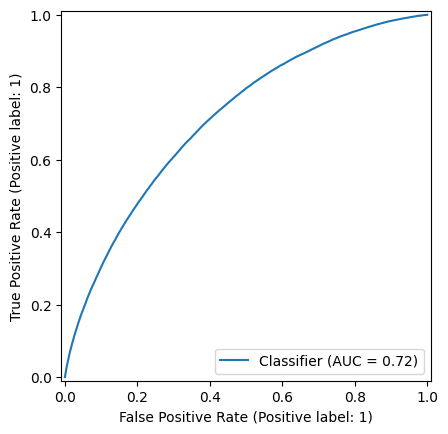

In [18]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)